# FIAP - Engenharia da Computação
## Computational Thinking for Engineering (CTE) - 1ECR
### Compêndio e Caderno Oficial de Exercícios: Python Standard, Raspberry Pi & Arduino C++

---
**Escopo do Documento:**
Este caderno compila de forma exaustiva e passo a passo os exercícios práticos, gabaritos oficiais e projetos laboratoriais desenvolvidos ao longo do curso de **Computational Thinking for Engineering**:
1. **Módulo 1:** Algoritmos Clássicos e Programação Python Padrão (Decisão, Laços, Funções, Equações);
2. **Módulo 2:** Automação Industrial e Controle com Raspberry Pi / GPIO (Esteiras, Sensores Ópticos, Motores DC, Triagem);
3. **Módulo 3:** Eletrônica Embarcada e Microcontrolador Arduino C++ (Semáforos, Displays de 7 Segmentos, Entradas Analógicas LDR/Potenciômetro, PWM e Atuadores);
4. **Módulo 4:** Simulação e Verificação Numérica com Gráficos Analíticos de Desempenho.

In [ ]:
# Setup de Bibliotecas para Simulação e Visualização Gráfica
import matplotlib.pyplot as plt
import numpy as np
import math

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Ambiente de Computação Científica e Automação inicializado com sucesso!')

---
## Módulo 1: Programação Python Padrão - Algoritmos Fundamentais

Nesta seção são implementadas funções canônicas baseadas na lista de exercícios oficiais de CTE.


### Exercícios 1 a 4: Validação Numérica e Comparações
- **Exercício 1:** Função que identifica se um valor é estritamente positivo (> 0).
- **Exercício 2:** Função que verifica se o valor é nulo (igual a zero).
- **Exercício 3:** Função que recebe três números inteiros e retorna o maior deles.
- **Exercício 4:** Função que calcula a média ponderada de três notas com pesos 2, 3 e 5.

In [ ]:
def eh_positivo(x):
    return x > 0

def eh_nulo(x):
    return x == 0

def maior_de_tres(a, b, c):
    return max(a, b, c)

def media_ponderada(n1, n2, n3):
    # Pesos: 2, 3 e 5
    peso_total = 2 + 3 + 5
    return (n1 * 2 + n2 * 3 + n3 * 5) / peso_total

# Testes de validação
print('eh_positivo(15):', eh_positivo(15))
print('eh_positivo(-4):', eh_positivo(-4))
print('eh_nulo(0):', eh_nulo(0))
print('maior_de_tres(12, 45, 29):', maior_de_tres(12, 45, 29))
print('media_ponderada(7.0, 8.5, 9.0):', round(media_ponderada(7.0, 8.5, 9.0), 2))

### Exercício 11: Conversão Termométrica (Celsius $\leftrightarrow$ Fahrenheit)
Relação termodinâmica:
$$C = \frac{5 \cdot (F - 32)}{9} \quad \Longleftrightarrow \quad F = \frac{9 \cdot C}{5} + 32$$

In [ ]:
def converter_temperatura(valor, escala_origem):
    escala = escala_origem.upper().strip()
    if escala == 'C':
        # Converter Celsius para Fahrenheit
        f = (9.0 * valor / 5.0) + 32.0
        return f, 'F'
    elif escala == 'F':
        # Converter Fahrenheit para Celsius
        c = 5.0 * (valor - 32.0) / 9.0
        return c, 'C'
    else:
        raise ValueError('Escala deve ser C ou F')

# Testes
temp_f, _ = converter_temperatura(100, 'C')
temp_c, _ = converter_temperatura(32, 'F')
print(f'100 °C = {temp_f:.1f} °F (Ponto de ebulição da água)')
print(f'32 °F = {temp_c:.1f} °C (Ponto de fusão do gelo)')

### Exercício 20: Resolução da Equação de Segundo Grau (Fórmula de Bháskara)
Dada $ax^2 + bx + c = 0$, o discriminante é:
$$\Delta = b^2 - 4ac$$
- $\Delta > 0$: duas raízes reais distintas $x_1, x_2 = \frac{-b \pm \sqrt{\Delta}}{2a}$
- $\Delta = 0$: uma raiz real dupla $x = \frac{-b}{2a}$
- $\Delta < 0$: raízes complexas conjugadas

In [ ]:
def resolver_bhaskara(a, b, c):
    if a == 0:
        return 'Não é equação de 2º grau (a = 0)'
    delta = b**2 - 4*a*c
    if delta > 0:
        x1 = (-b + math.sqrt(delta)) / (2*a)
        x2 = (-b - math.sqrt(delta)) / (2*a)
        return (x1, x2)
    elif delta == 0:
        x = -b / (2*a)
        return (x,)
    else:
        parte_real = -b / (2*a)
        parte_imag = math.sqrt(-delta) / (2*a)
        return (complex(parte_real, parte_imag), complex(parte_real, -parte_imag))

print('Equação x^2 - 5x + 6 = 0:', resolver_bhaskara(1, -5, 6))
print('Equação x^2 - 4x + 4 = 0:', resolver_bhaskara(1, -4, 4))
print('Equação x^2 + 1 = 0:', resolver_bhaskara(1, 0, 1))

### Exercícios 28, 36 e 37: Lógica Analítica, Divisores e Somatórios
- **Exercício 28:** Cálculo de peso ideal por gênero e altura.
- **Exercício 36:** Contagem exata de divisores positivos de um inteiro $N$.
- **Exercício 37:** Somatório de Gauss: $\sum_{k=1}^N k = \frac{N(N+1)}{2}$.

In [ ]:
def peso_ideal(altura_m, sexo):
    s = sexo.upper().strip()
    if s == 'M':
        return 72.7 * altura_m - 58.0
    elif s == 'F':
        return 62.1 * altura_m - 44.7
    else:
        raise ValueError('Sexo deve ser M ou F')

def contar_divisores(n):
    if n <= 0: return 0
    divs = [d for d in range(1, n + 1) if n % d == 0]
    return len(divs), divs

def somatorio_positivo(n):
    if n <= 0: return 0
    return sum(range(1, n + 1))

print(f'Peso ideal Homem 1.80m: {peso_ideal(1.80, "M"):.2f} kg')
print(f'Peso ideal Mulher 1.65m: {peso_ideal(1.65, "F"):.2f} kg')
qtd, lista = contar_divisores(28)
print(f'Divisores de 28: {lista} (Total: {qtd})')
print(f'Somatório de 1 a 100: {somatorio_positivo(100)} (Gauss: {100*101//2})')

---
## Módulo 2: Automação Industrial e Raspberry Pi (Python GPIO)

Aqui são apresentados os exercícios de automação e controle industrial contidos na **Lista Oficial de Raspberry Pi** da FIAP.


### Exercício 1 e 2 (RPi): Controle de Esteira Transportadora com Motor DC e Sensores Ópticos
<div align="center">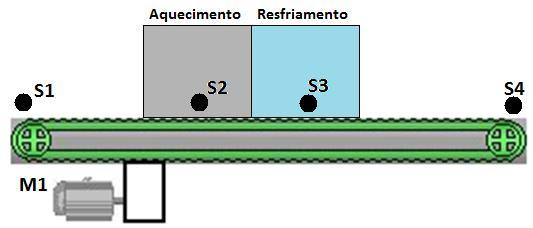</div>
**Enunciado do Problema:**
1. Uma peça é colocada na esteira na posição do sensor $S_1$. Ao detectar a peça, o motor $M_1$ é ligado imediatamente.
2. A esteira conduz a peça até o sensor $S_2$, quando então o motor $M_1$ é desligado.
3. O sistema conta o número de peças transportadas e sinaliza em uma lâmpada $L_1$ quando uma caixa atinge 10 peças, interrompendo o ciclo para troca de embalagem.
4. Simulação em Raspberry Pi:
   - Sensores $S_1$ e $S_2$: simulados por Pushbuttons com resistor pull-up/pull-down.
   - Lâmpada $L_1$: simulada por LED indicador.
   - Motor $M_1$: acionado via relé/transistor chaveador.

In [ ]:
# Simulação Lógica do Sistema da Esteira Transportadora em Python
class EsteiraTransportadoraSim:
    def __init__(self, limite_caixa=10):
        self.limite_caixa = limite_caixa
        self.motor_m1 = False
        self.lampada_l1 = False
        self.contador_pecas = 0
        self.log_estados = []

    def acionar_sensor_s1(self):
        """Sensor de entrada detecta peca: liga motor M1 se caixa nao estiver cheia."""
        if not self.lampada_l1:
            self.motor_m1 = True
            self.log_estados.append(('S1 acionado', 'M1 LIGADO', self.contador_pecas))
        else:
            self.log_estados.append(('S1 acionado', 'BLOQUEADO - Caixa Cheia', self.contador_pecas))

    def acionar_sensor_s2(self):
        """Sensor de fim de curso detecta peca: desliga motor M1 e incrementa peca."""
        if self.motor_m1:
            self.motor_m1 = False
            self.contador_pecas += 1
            if self.contador_pecas >= self.limite_caixa:
                self.lampada_l1 = True
            self.log_estados.append(('S2 acionado', 'M1 DESLIGADO', self.contador_pecas))

    def trocar_caixa_reset(self):
        """Botao B1 pressionado pelo operador apos troca da caixa."""
        self.contador_pecas = 0
        self.lampada_l1 = False
        self.log_estados.append(('B1 pressionado', 'L1 APAGADA / RESET', self.contador_pecas))

# Executando ciclo de simulacao com 10 pecas
esteira = EsteiraTransportadoraSim(limite_caixa=5)
for i in range(1, 7):
    esteira.acionar_sensor_s1()
    esteira.acionar_sensor_s2()

for evento, status, count in esteira.log_estados:
    print(f'Evento: {evento:<16} | Status Motor: {status:<24} | Peças na Caixa: {count}')

print(f'Estado Final da Lâmpada L1 (Caixa Cheia): {esteira.lampada_l1}')
esteira.trocar_caixa_reset()
print(f'Após B1 (Reset): Lâmpada L1 = {esteira.lampada_l1}, Peças = {esteira.contador_pecas}')

### Exercício 4 (RPi): Triagem e Seleção Automatizada de Caixas por Altura
<div align="center">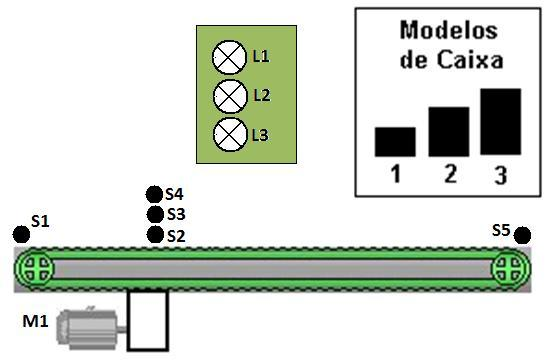</div>
**Enunciado do Problema:**
No sistema de triagem, uma caixa entra em $S_1$, ligando o motor $M_1$ até o sensor de inspeção $S_5$.
Sensores de altura fotoelétricos ($S_2, S_3, S_4$) identificam o perfil geométrico da caixa:
- **Caixa Tipo 1 (Pequena):** Bloqueia apenas sensor $S_2$ $\rightarrow$ Desviada para Rampa 1 via Pistão/Atuador $P_1$;
- **Caixa Tipo 2 (Média):** Bloqueia sensores $S_2$ e $S_3$ $\rightarrow$ Desviada para Rampa 2 via Pistão/Atuador $P_2$;
- **Caixa Tipo 3 (Grande):** Bloqueia $S_2, S_3$ e $S_4$ $\rightarrow$ Segue em frente pela esteira principal para Descarte/Saída 3.

In [ ]:
def classificar_caixa(s2, s3, s4):
    """
    Classifica a caixa com base no perfil de sensores fotoelétricos.
    Retorna o tipo da caixa e a rampa de direcionamento.
    """
    if s2 and s3 and s4:
        return 'Caixa Grande (Tipo 3)', 'Saída Direta (Rampa 3)'
    elif s2 and s3 and not s4:
        return 'Caixa Média (Tipo 2)', 'Atuar Pistão 2 (Rampa 2)'
    elif s2 and not s3 and not s4:
        return 'Caixa Pequena (Tipo 1)', 'Atuar Pistão 1 (Rampa 1)'
    else:
        return 'Perfil Indefinido / Erro de Leitura', 'Parar Esteira'

# Teste dos perfis de triagem
cenarios = [
    (True, False, False),
    (True, True, False),
    (True, True, True),
    (False, True, False) # Anomalia
]

for s2, s3, s4 in cenarios:
    tipo, acao = classificar_caixa(s2, s3, s4)
    print(f'Sensores [S2={int(s2)}, S3={int(s3)}, S4={int(s4)}] -> {tipo:<24} | Ação: {acao}')

---
## Módulo 3: Eletrônica Embarcada e Microcontroladores Arduino C++

Nesta seção compilamos os códigos `.ino` reais e esquemas eletrônicos extraídos das listas oficiais e avaliações práticas da FIAP.


### Avaliação Oficial NAC 2: Questões Práticas de Hardware
A prova prática exigiu o controle coordenado de atuadores e leitura analógica com buzzer/LED.
<div align="center">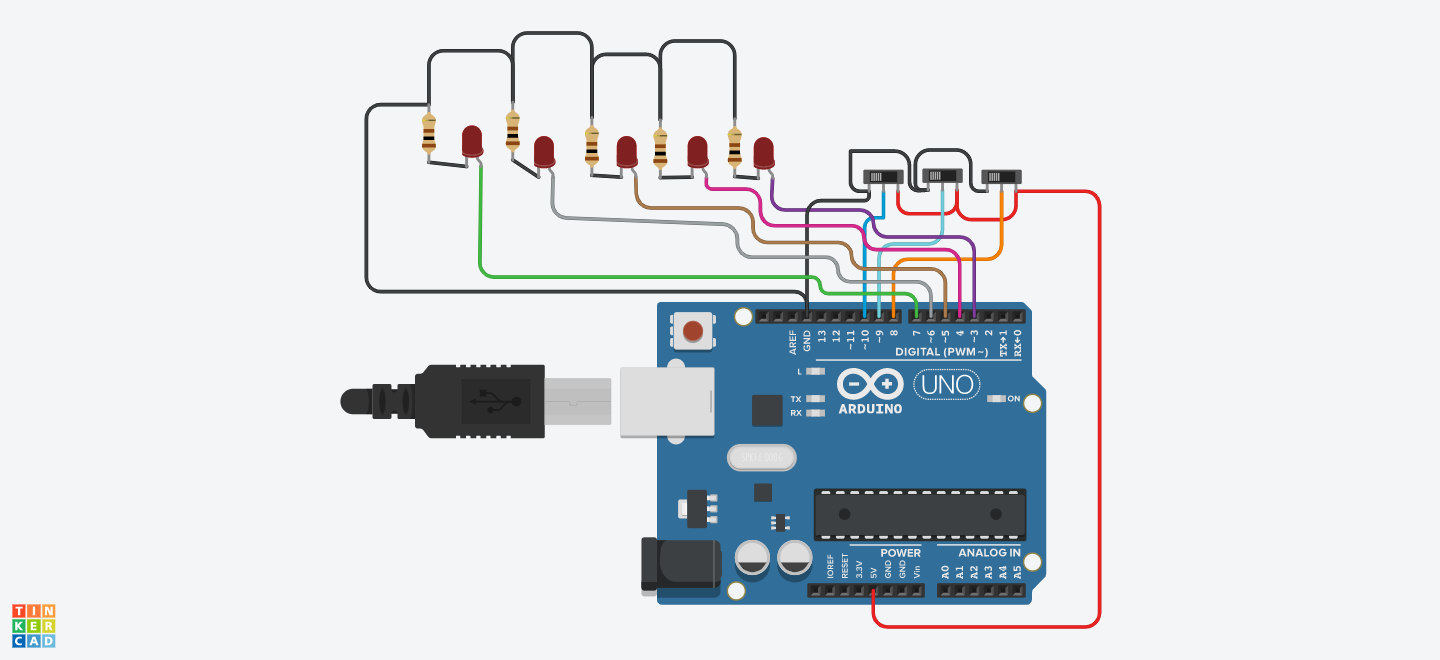</div>
#### Código C++ da Questão 1 (NAC 2 - Semáforo / Controle Sequencial):
```cpp
// Gabarito NAC 2 - Questão 1 (Arduino C++)
const int ledVermelho = 12;
const int ledAmarelo  = 11;
const int ledVerde    = 10;

void setup() {
  pinMode(ledVermelho, OUTPUT);
  pinMode(ledAmarelo, OUTPUT);
  pinMode(ledVerde, OUTPUT);
}

void loop() {
  digitalWrite(ledVerde, HIGH);
  delay(5000);
  digitalWrite(ledVerde, LOW);
  
  digitalWrite(ledAmarelo, HIGH);
  delay(2000);
  digitalWrite(ledAmarelo, LOW);
  
  digitalWrite(ledVermelho, HIGH);
  delay(5000);
  digitalWrite(ledVermelho, LOW);
}
```

#### Código C++ da Questão 2 (NAC 2 - Leitura de Sensor Analógico e Alarme Sonoro/Visual):
```cpp
// Gabarito NAC 2 - Questão 2 (Arduino C++)
const int pinoLDR = A0;
const int pinoBuzzer = 8;
const int pinoLED = 9;

void setup() {
  pinMode(pinoBuzzer, OUTPUT);
  pinMode(pinoLED, OUTPUT);
  Serial.begin(9600);
}

void loop() {
  int leitura = analogRead(pinoLDR);
  Serial.print("Luminosidade: ");
  Serial.println(leitura);
  
  if (leitura < 400) { // Limiar de escuridão
    digitalWrite(pinoLED, HIGH);
    tone(pinoBuzzer, 1000);
  } else {
    digitalWrite(pinoLED, LOW);
    noTone(pinoBuzzer);
  }
  delay(200);
}
```

### Exercício Extra: Decodificador e Acionamento de Display de 7 Segmentos
<div align="center">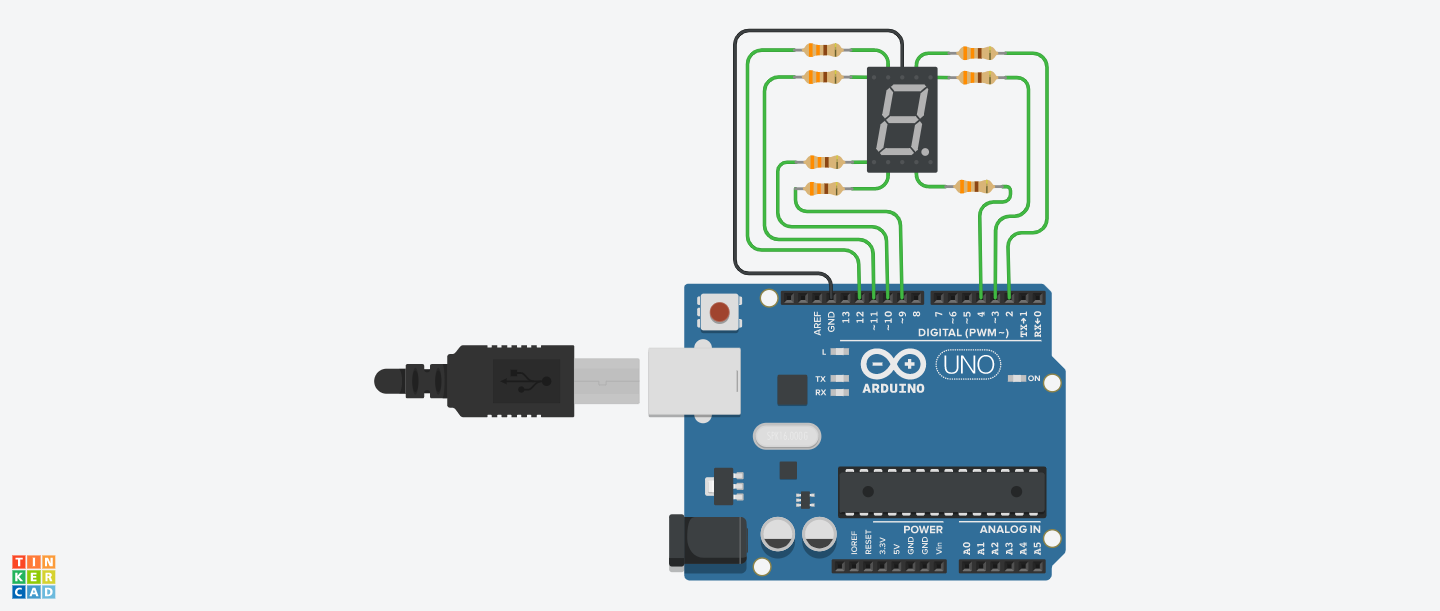</div>
Mapeamento dos 7 segmentos catodo comum (a, b, c, d, e, f, g) nos pinos digitais do Arduino:
```cpp
// Gabarito Oficial: Display de 7 Segmentos (C++ Arduino)
// Pinos dos segmentos a, b, c, d, e, f, g
const int segA = 2;
const int segB = 3;
const int segC = 4;
const int segD = 5;
const int segE = 6;
const int segF = 7;
const int segG = 8;

// Matriz com os padroes de 0 a 9 para catodo comum
const byte digitos[10][7] = {
  {1, 1, 1, 1, 1, 1, 0}, // 0
  {0, 1, 1, 0, 0, 0, 0}, // 1
  {1, 1, 0, 1, 1, 0, 1}, // 2
  {1, 1, 1, 1, 0, 0, 1}, // 3
  {0, 1, 1, 0, 0, 1, 1}, // 4
  {1, 0, 1, 1, 0, 1, 1}, // 5
  {1, 0, 1, 1, 1, 1, 1}, // 6
  {1, 1, 1, 0, 0, 0, 0}, // 7
  {1, 1, 1, 1, 1, 1, 1}, // 8
  {1, 1, 1, 1, 0, 1, 1}  // 9
};

void setup() {
  for (int pino = 2; pino <= 8; pino++) {
    pinMode(pino, OUTPUT);
  }
}

void mostrarDigito(int num) {
  for (int seg = 0; seg < 7; seg++) {
    digitalWrite(seg + 2, digitos[num][seg]);
  }
}

void loop() {
  for (int count = 0; count < 10; count++) {
    mostrarDigito(count);
    delay(1000);
  }
}
```

### Exercício Arquivo 6: Modulação por Largura de Pulso (PWM) e Fade de LED
<div align="center">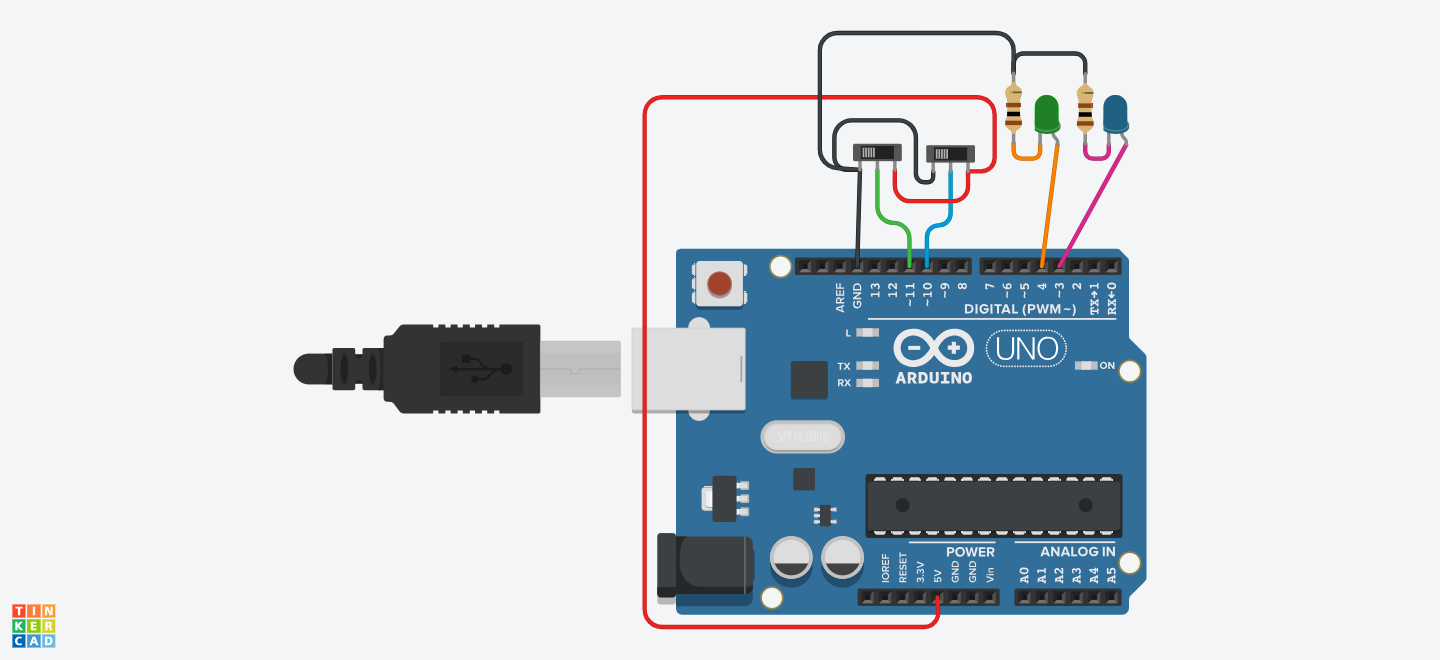</div>
Circuito com potenciômetro conectado à porta analógica A0 e LED com controle PWM no pino 9:
```cpp
// Gabarito Oficial Arq6_Exe2 (Arduino C++)
const int pinoPot = A0;
const int pinoLED = 9; // Pino PWM

void setup() {
  pinMode(pinoLED, OUTPUT);
  Serial.begin(9600);
}

void loop() {
  int valPot = analogRead(pinoPot); // Leitura de 0 a 1023 (10 bits ADC)
  int brilho = map(valPot, 0, 1023, 0, 255); // Mapeia para PWM 8 bits
  analogWrite(pinoLED, brilho);
  
  Serial.print("ADC: ");
  Serial.print(valPot);
  Serial.print(" -> PWM: ");
  Serial.println(brilho);
  delay(30);
}
```

---
## Módulo 4: Análise Gráfica e Simulação dos Sinais Digitais e PWM

Visualização da resposta temporal dos sensores e curvas de transferência do conversor AD / PWM.

In [ ]:
# Simulação analítica de sinais: ADC 10 bits vs Sinal PWM 8 bits e Curva de Resposta
t = np.linspace(0, 10, 500)
tensao_analogica = 2.5 + 2.4 * np.sin(2 * np.pi * 0.2 * t) # Sinal analógico de 0.1V a 4.9V
adc_leitura = np.clip(np.round((tensao_analogica / 5.0) * 1023), 0, 1023)
duty_cycle_pwm = (adc_leitura / 1023.0) * 100.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Gráfico 1: Tensão e Conversão ADC
ax1.plot(t, tensao_analogica, color='#1f77b4', lw=2, label='Tensão no Pino A0 (V)')
ax1.set_ylabel('Tensão (V)', color='#1f77b4', fontsize=11, fontweight='bold')
ax1.set_title('Simulação de Aquisição de Dados no Arduino (Conversor A/D 10 bits)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# Eixo secundário para contagem ADC
ax1_adc = ax1.twinx()
ax1_adc.plot(t, adc_leitura, color='#ff7f0e', ls='--', alpha=0.7, label='Valor ADC (0 a 1023)')
ax1_adc.set_ylabel('Contagem ADC (10-bit)', color='#ff7f0e', fontsize=11, fontweight='bold')
ax1_adc.legend(loc='lower right')

# Gráfico 2: Duty Cycle PWM Resultante
ax2.plot(t, duty_cycle_pwm, color='#2ca02c', lw=2, label='Duty Cycle PWM Pino 9 (%)')
ax2.set_xlabel('Tempo de Simulação (s)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ciclo Ativo (%)', color='#2ca02c', fontsize=11, fontweight='bold')
ax2.set_title('Controle de Potência por Modulação PWM (0 a 255 -> 0% a 100%)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()